# Train ORL Balanced

Notebook nay chi train tu bundle da duoc split truoc. Anh test goc duoc giu nguyen trong `manifest_test.csv` va `test_file_paths` de dung cho web demo.

In [16]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if not (ROOT / "src").exists():
    raise RuntimeError("Could not locate repo root containing 'src'.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml')

In [17]:
import pandas as pd

from src.process import load_processed_dataset_bundle_for_preset
from src.pipelines import train_pca_knn, train_pca_svm
from src.utils import compare_models, plot_confusion_matrix, plot_explained_variance, save_metrics


## Training config

In [18]:
config = {
    "dataset_name": "orl",
    "preset_name": "balanced",
    "role": "balanced",
    "n_components": 20,
    "knn_k": 3,
    "knn_metric": "euclidean",
    "svm_C": 1.0,
    "svm_kernel": "linear",
    "svm_gamma": "scale",
    "svm_max_iter": 50,
}

pd.Series(config)


dataset_name          orl
preset_name      balanced
role             balanced
n_components           20
knn_k                   3
knn_metric      euclidean
svm_C                 1.0
svm_kernel         linear
svm_gamma           scale
svm_max_iter           50
dtype: object

## Load pre-split processed bundle

In [19]:
bundle = load_processed_dataset_bundle_for_preset(
    dataset_name=config["dataset_name"],
    preset_name=config["preset_name"],
)

summary = bundle["summary"]
label_names = bundle["metadata"]["label_names"]
confusion_labels = label_names if len(label_names) <= 20 else None

X_train = bundle["X_train"]
X_test = bundle["X_test"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]
test_manifest_path = Path(bundle["output_dir"]) / "manifest_test.csv"

pd.Series({
    "dataset_name": summary["dataset_name"],
    "role": config["role"],
    "samples_total": summary["samples_total"],
    "classes_total": summary["classes_total"],
    "train_shape": summary["train_shape"],
    "test_shape": summary["test_shape"],
    "bundle_dir": bundle["output_dir"],
    "test_manifest": str(test_manifest_path),
    "test_images_raw": len(bundle["test_file_paths"]),
})


dataset_name                                                     orl
role                                                        balanced
samples_total                                                    400
classes_total                                                     40
train_shape                                             [320, 10304]
test_shape                                               [80, 10304]
bundle_dir         D:\HCMUTE_project\Math_for_ML\math_for_ml\data...
test_manifest      D:\HCMUTE_project\Math_for_ML\math_for_ml\data...
test_images_raw                                                   80
dtype: object

## Train PCA + KNN

In [20]:
knn_model = train_pca_knn(
    X_train,
    y_train,
    n_components=config["n_components"],
    k=config["knn_k"],
    metric=config["knn_metric"],
)

knn_eval = knn_model.evaluate(X_test, y_test)
pd.Series({
    "accuracy": knn_eval["accuracy"],
    "train_time": knn_eval["train_time"],
})


accuracy      0.875000
train_time    0.122732
dtype: float64

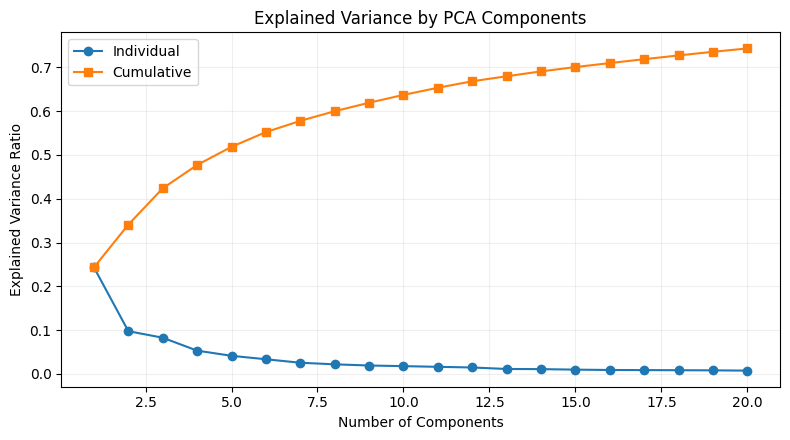

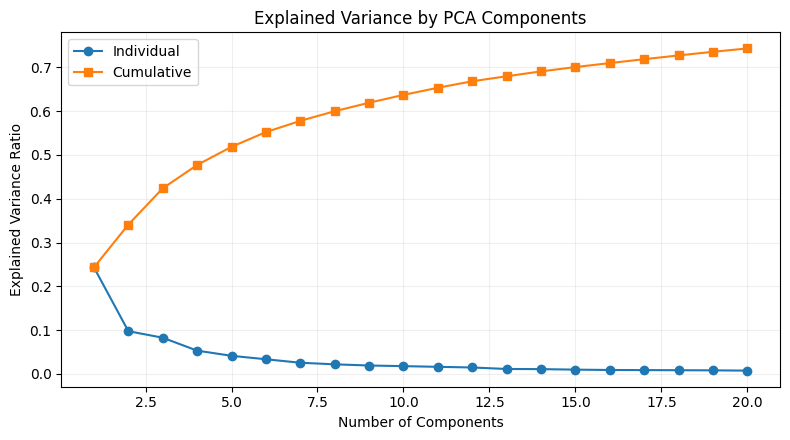

In [21]:
plot_explained_variance(knn_model.pca.explained_variance_ratio_)


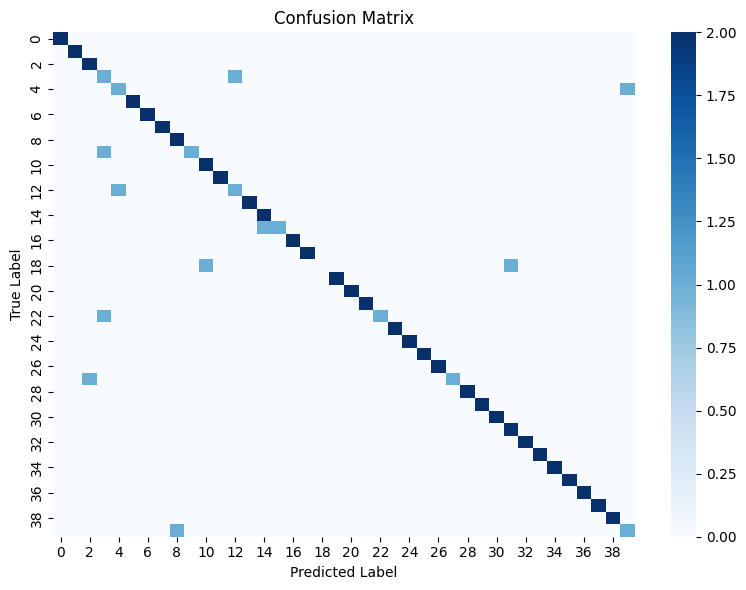

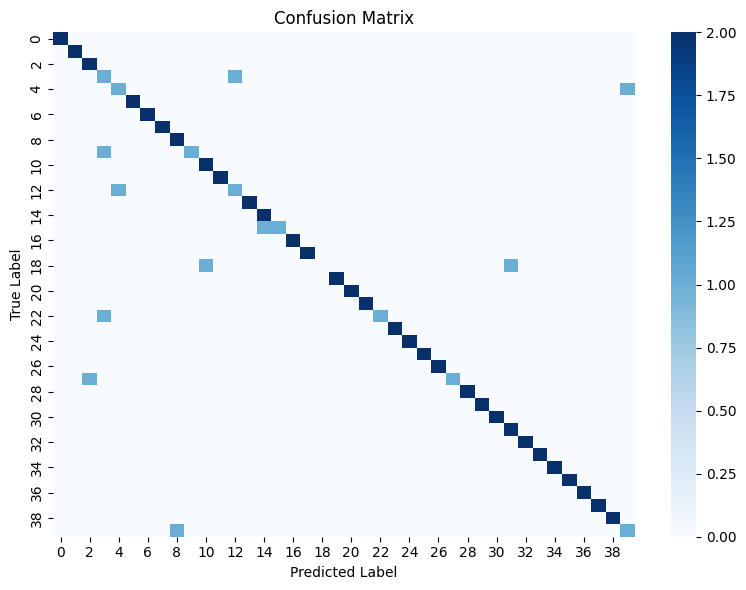

In [22]:
plot_confusion_matrix(knn_eval["confusion_matrix"], labels=confusion_labels)


## Train PCA + SVM

In [23]:
svm_model = train_pca_svm(
    X_train,
    y_train,
    n_components=config["n_components"],
    C=config["svm_C"],
    kernel=config["svm_kernel"],
    gamma=config["svm_gamma"],
    max_iter=config["svm_max_iter"],
)

svm_eval = svm_model.evaluate(X_test, y_test)
pd.Series({
    "accuracy": svm_eval["accuracy"],
    "train_time": svm_eval["train_time"],
})


accuracy      0.937500
train_time    0.813172
dtype: float64

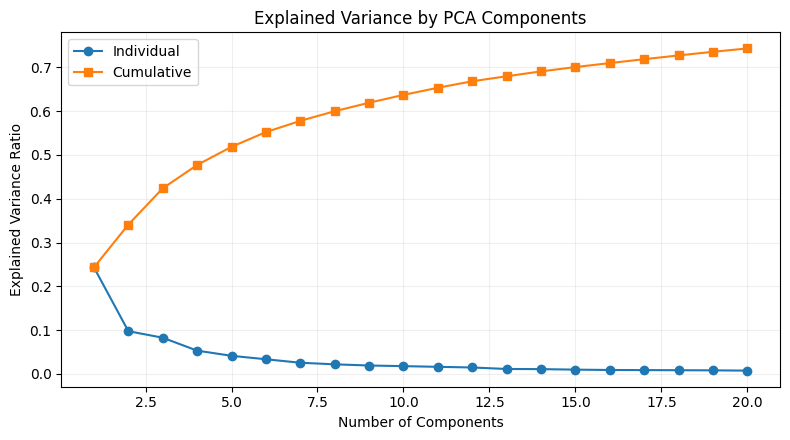

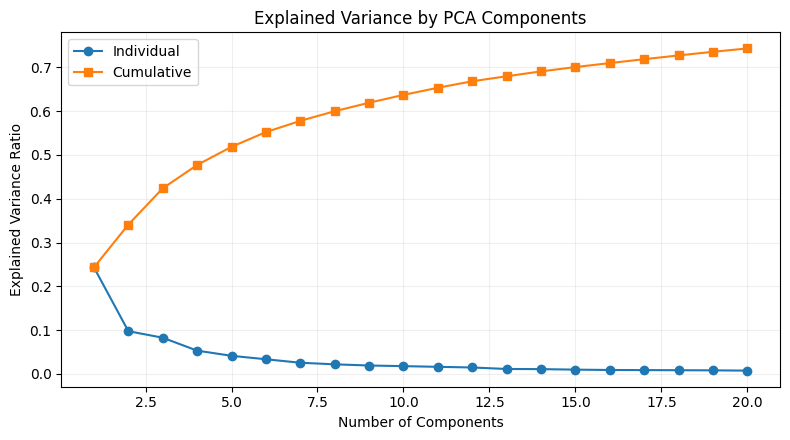

In [24]:
plot_explained_variance(svm_model.pca.explained_variance_ratio_)


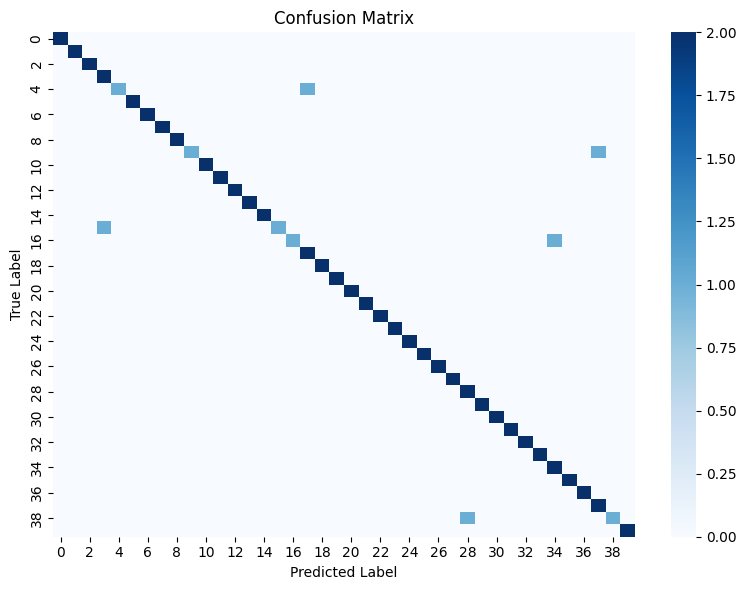

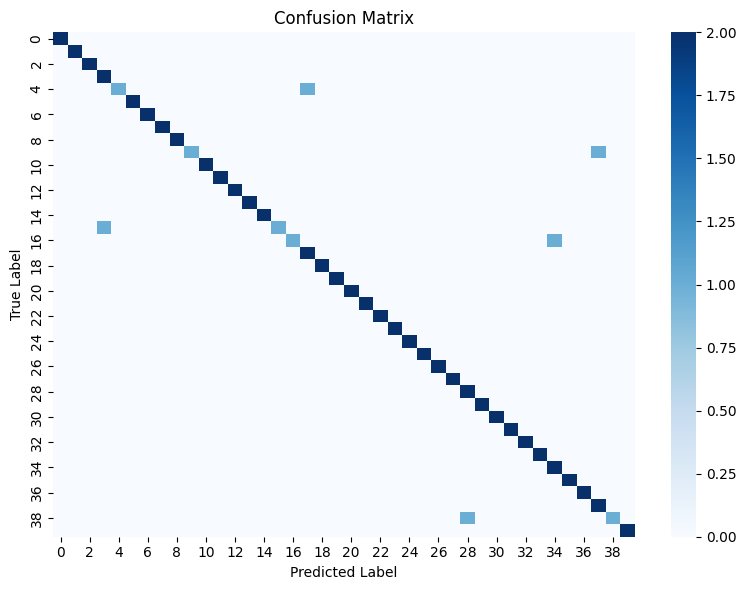

In [25]:
plot_confusion_matrix(svm_eval["confusion_matrix"], labels=confusion_labels)


## Compare and save metrics

In [26]:
comparison_df = compare_models(
    {
        "PCA+KNN": knn_eval,
        "PCA+SVM": svm_eval,
    }
)

comparison_df


         Accuracy  Precision  Recall  F1-Score  Train Time
Model                                                     
PCA+KNN    0.8750     0.8792  0.8750    0.8642       0.123
PCA+SVM    0.9375     0.9583  0.9375    0.9333       0.813


,Accuracy,Precision,Recall,F1-Score,Train Time
Model,,,,,
PCA+KNN,0.8750,0.8792,0.8750,0.8642,0.123
PCA+SVM,0.9375,0.9583,0.9375,0.9333,0.813


In [27]:
metrics_path = ROOT / "results" / "metrics" / "orl_balanced_comparison.csv"
save_metrics(comparison_df, metrics_path)
metrics_path


[metrics] Đã lưu: D:\HCMUTE_project\Math_for_ML\math_for_ml\results\metrics\orl_balanced_comparison.csv


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml/results/metrics/orl_balanced_comparison.csv')

## Optional: save trained models

In [28]:
model_dir = ROOT / "webapp" / "saved_models"
model_dir.mkdir(parents=True, exist_ok=True)

knn_path = model_dir / "pca_knn_orl_balanced.pkl"
svm_path = model_dir / "pca_svm_orl_balanced.pkl"

knn_model.save_model(knn_path)
svm_model.save_model(svm_path)

pd.Series({
    "knn_model": str(knn_path),
    "svm_model": str(svm_path),
})


AttributeError: 'PCAKNNPipeline' object has no attribute 'save_model'